# Primer modelo baseline con regresión logística

En esta libreta se buscó:

1. Cargar el dataset limpio preparado en la libreta 003.
2. Separar variables predictoras y variable objetivo.
3. Dividir los datos en entrenamiento y prueba.
4. Construir un primer modelo baseline de regresión logística.
5. Obtener predicciones de clase y probabilidades.
6. Evaluar el desempeño del modelo con métricas básicas.
7. Interpretar los primeros resultados.

## Contexto

Después de la exploración y limpieza inicial del dataset, el siguiente paso natural es construir un modelo base que permita predecir si un cliente incurrirá en incumplimiento de pago en el siguiente mes.

La regresión logística es una elección adecuada para esta primera etapa porque es un modelo clásico de clasificación binaria, produce probabilidades interpretables y sirve como punto de comparación para modelos más complejos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## Carga del dataset limpio

Se carga la versión depurada del conjunto de datos generada en la sesión anterior.

In [2]:
f = "../data/default_credit_clean.csv" # ruta al archivo CSV
df = pd.read_csv(f)
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default_next_month,SEX_LABEL,EDUCATION_LABEL,MARRIAGE_LABEL,AGE_GROUP
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1,Femenino,Universidad,Casado,20-29
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1,Femenino,Universidad,Soltero,20-29
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0,Femenino,Universidad,Soltero,30-39
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0,Femenino,Universidad,Casado,30-39
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0,Masculino,Universidad,Casado,50-59


Revisión rapida de la estructura del dataset

In [3]:
print("Dimensiones:", df.shape)
print("\nColumnas:")
print(df.columns.tolist())

Dimensiones: (30000, 29)

Columnas:
['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default_next_month', 'SEX_LABEL', 'EDUCATION_LABEL', 'MARRIAGE_LABEL', 'AGE_GROUP']


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 29 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   ID                  30000 non-null  int64
 1   LIMIT_BAL           30000 non-null  int64
 2   SEX                 30000 non-null  int64
 3   EDUCATION           30000 non-null  int64
 4   MARRIAGE            30000 non-null  int64
 5   AGE                 30000 non-null  int64
 6   PAY_1               30000 non-null  int64
 7   PAY_2               30000 non-null  int64
 8   PAY_3               30000 non-null  int64
 9   PAY_4               30000 non-null  int64
 10  PAY_5               30000 non-null  int64
 11  PAY_6               30000 non-null  int64
 12  BILL_AMT1           30000 non-null  int64
 13  BILL_AMT2           30000 non-null  int64
 14  BILL_AMT3           30000 non-null  int64
 15  BILL_AMT4           30000 non-null  int64
 16  BILL_AMT5           30000 non-null  int64
 17  BILL

## Separación de predictores y variable objetivo

La variable objetivo es `default_next_month`, mientras que el resto de las variables serán consideradas como predictores.

Se excluyen las columnas auxiliares de texto o etiquetas, así como el identificador `ID`.

In [5]:
cols_to_drop = ["default_next_month"]

optional_drop = ["ID", "SEX_LABEL", 'EDUCATION_LABEL', 'MARRIAGE_LABEL', 'AGE_GROUP' ]

# Verificar si las columnas opcionales existen antes de agregarlas a la lista de columnas a eliminar
for col in optional_drop:
    if col in df.columns:
        cols_to_drop.append(col)

X = df.drop(columns=cols_to_drop)
y = df["default_next_month"]

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (30000, 23)
Dimensiones de y: (30000,)


## Distribución de la variable objetivo

Antes de entrenar el modelo, es importante revisar qué tan balanceadas están las clases.

In [6]:
# Verificar la distribución de la variable objetivo
target_dist = y.value_counts().sort_index().to_frame("count")
target_dist["proportion"] = y.value_counts(normalize=True).sort_index()
target_dist

,count,proportion
default_next_month,,
0,23364,0.7788
1,6636,0.2212


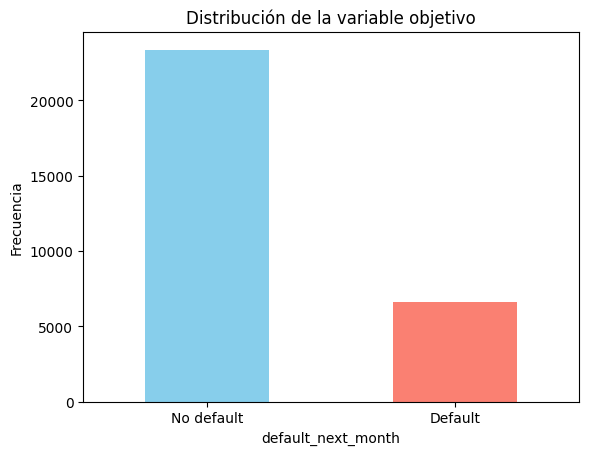

In [7]:
y.value_counts().sort_index().plot(kind="bar", color=["skyblue", "salmon"])
plt.xticks([0, 1], ["No default", "Default"], rotation=0)
plt.ylabel("Frecuencia")
plt.title("Distribución de la variable objetivo")
plt.show()

## División en entrenamiento y prueba

Se divide el conjunto de datos en dos partes:

- **entrenamiento**: para ajustar el modelo,
- **prueba**: para evaluar su desempeño en datos no vistos.

Se utiliza partición estratificada para conservar aproximadamente la misma proporción de clases en ambos subconjuntos.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (24000, 23)
X_test : (6000, 23)
y_train: (24000,)
y_test : (6000,)


* **`random_state=42` (Semilla de Aleatoriedad):** Su función es garantizar la **reproducibilidad**. Al fijar un número, aseguras que cada vez que ejecutes el código, los datos se mezclen exactamente igual. Sin esto, los resultados variarían en cada ejecución.
* **`stratify=y` (Muestreo Estratificado):** Mantiene la **misma proporción de clases** en los conjuntos de entrenamiento y prueba. Si el 22% de lostus datos originales son de la clase "Impago", el conjunto de prueba de 20% tendrá exactamente un 22% de clase impago. Vital para datos desbalanceados.


## Identificación de variables numéricas y categóricas

Para construir el pipeline de preprocesamiento, se distinguen las variables numéricas y categóricas.

In [9]:
categorical_features = ["SEX", "EDUCATION", "MARRIAGE", "AGE_GROUP"]
categorical_features = [col for col in categorical_features if col in X_train.columns]

numeric_features = [col for col in X_train.columns if col not in categorical_features]

print("Variables categóricas:")
print(categorical_features)

print("\nVariables numéricas:")
print(numeric_features)

Variables categóricas:
['SEX', 'EDUCATION', 'MARRIAGE']

Variables numéricas:
['LIMIT_BAL', 'AGE', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


## Preprocesamiento

Se aplican transformaciones distintas según el tipo de variable:

- **numéricas**: imputación por mediana y escalamiento.
- **categóricas**: imputación por moda y codificación one-hot.

Este paso se integra en un pipeline para evitar fugas de información y mantener el flujo de trabajo ordenado.

In [10]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

#### Transformador Numérico (`numeric_transformer`)
Se encarga de las columnas con números (ej. 'LIMIT_BAL', 'AGE', 'PAY_0', etc.).
1. **`SimpleImputer(strategy="median")`**: Rellena los valores nulos (`NaN`) usando la **mediana** de la columna. Es más robusto ante valores atípicos (outliers) que el promedio.
2. **`StandardScaler()`**: Escala los datos para que tengan media 0 y desviación estándar 1. Evita que variables con magnitudes grandes dominen a las de números pequeños durante el entrenamiento.

#### Transformador Categórico (`categorical_transformer`)
Se encarga de las columnas de texto o categorías (ej. país, género).
1. **`SimpleImputer(strategy="most_frequent")`**: Rellena los valores nulos con la categoría más común (la moda).
2. **`OneHotEncoder(drop="first", handle_unknown="ignore")`**: Convierte texto en columnas binarias (0s y 1s).
   * `drop="first"`: Evita la multicolinealidad eliminando la primera columna de cada categoría generada.
   * `handle_unknown="ignore"`: Si aparecen categorías nuevas en los datos de prueba, el modelo las ignora llenando la fila con ceros, evitando errores en ejecución.

#### El Preprocesador Maestro (`ColumnTransformer`)
Es el orquestador que une las tuberías y las aplica al DataFrame original.
* Dirige las columnas listadas en `numeric_features` hacia el `numeric_transformer`.
* Dirige las columnas listadas en `categorical_features` hacia el `categorical_transformer`.

Usar estas estructuras automatizadas evita la **fuga de datos (data leakage)**, garantizando que estadísticas como la mediana se calculen *únicamente* con los datos de entrenamiento y se apliquen de forma ciega a los datos de prueba y datos futuros.

## Modelo baseline: regresión logística

Se construye una regresión logística como primer modelo baseline para predecir incumplimiento.

In [11]:
log_reg = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

#### El Pipeline Principal (`Pipeline`)
Un `Pipeline` en Scikit-Learn garantiza que una serie de pasos se ejecuten en un orden estricto. La gran ventaja es que tratas a todo este conducto como si fuera un solo modelo. 

* **Paso 1: `"preprocessor", preprocessor`**:  `ColumnTransformer` que configuramos hace un momento". Esto limpiará los nulos, escalará los números y convertirá el texto en ceros y unos.
* **Paso 2: `"model", LogisticRegression(...)`**: Una vez que los datos salen limpios del preprocesador, entran directamente a este paso, que es el algoritmo de Machine Learning.

#### El Modelo (`LogisticRegression`)

* **`max_iter=2000` (Iteraciones máximas):** La Regresión Logística aprende intentando encontrar la mejor línea matemática para separar tus datos, ajustándose poco a poco en múltiples "intentos" (iteraciones). El valor por defecto de Scikit-Learn suele ser 100, lo cual a veces es muy poco y provoca un error molesto llamado `ConvergenceWarning` (significa que el modelo se rindió antes de encontrar la mejor respuesta). Al ponerlo en 2000, le das tiempo y espacio de sobra al algoritmo para que haga los cálculos necesarios hasta llegar a su mejor versión.
* **`random_state=42` (Semilla de aleatoriedad):** Igual que en la división de datos. Muchos algoritmos tienen pequeños componentes de azar al inicio de su entrenamiento. Fijar este número asegura que, si vuelves a correr el modelo mañana, el algoritmo tomará exactamente las mismas decisiones matemáticas y te dará el mismo resultado.

## Entrenamiento del modelo

In [12]:
log_reg.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

#### Contenedor Principal (`Pipeline`)
* **La caja grande con líneas punteadas:** Representa el objeto maestro final (el que llamamos `log_reg` en el último código). Todo lo que está dentro de esta caja se ejecuta como un solo bloque. Si entran datos crudos por arriba, salen predicciones por abajo.

#### División del Trabajo (`preprocessor: ColumnTransformer`)
* **La caja interior punteada:** Es tu `ColumnTransformer`. Actúa como un guardia de tráfico que separa tus datos iniciales en dos carriles distintos dependiendo de qué tipo de columna sean.

#### Los Dos Carriles Paralelos
* **Carril Izquierdo (`num`):** Las columnas con números viajan por aquí.
    * Primero pasan por el **`SimpleImputer`** (donde los huecos vacíos se rellenan con la mediana).
    * Luego pasan al **`StandardScaler`** (donde los números se nivelan para que no haya variables gigantes que opaquen a las pequeñas).
* **Carril Derecho (`cat`):** Las columnas con texto o categorías viajan por aquí.
    * Pasan por su propio **`SimpleImputer`** (donde los huecos se rellenan con la palabra más frecuente).
    * Luego entran al **`OneHotEncoder`** (donde el texto se transforma en columnas de 0s y 1s).

#### La Convergencia y el Cerebro (`LogisticRegression`)
* **La unión de las líneas:** Debajo de los carriles `num` y `cat`, las líneas grises se unen en una sola. Esto significa que los datos numéricos (ya limpios y escalados) y los datos categóricos (ya convertidos a 0s y 1s) se vuelven a fusionar en una sola tabla perfecta y ordenada.
* **La última parada:** Esa tabla limpia entra directamente a la caja de **`LogisticRegression`**. Este es el algoritmo de Machine Learning que analiza los datos procesados, aprende los patrones matemáticos y emite el resultado final (la predicción).

El diagrama confirma que el diseño funciona como un reloj. Cuando se utilice este modelo en el futuro, no tendremos que aplicar los pasos uno por uno; simplemente le damos la tabla cruda al inicio del mapa, y el sistema seguirá esta ruta automáticamente hasta dar la respuesta al final.

## Predicciones del modelo

Se obtienen:

- predicciones de clase (`0` o `1`),
- probabilidades estimadas de incumplimiento.